### **Technical Indicators**

**Load Libraries**

In [1]:
import pandas as pd
import talib
import os
import matplotlib.pyplot as plt

**Setup Paths**

In [2]:
data_dir = "../data/raw/yfinance_data/Data"
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
processed_data = {}

def apply_indicators(df):
    """
    Applies technical indicators. 
    Checks for 'Adj Close' first, falls back to 'Close' if missing.
    """
    df = df.sort_index()
    
    # Identify the correct column for price
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'Close' in df.columns:
        price_col = 'Close'
    else:
        # If neither exists, print columns to help debug and skip
        print(f"Error: No Close column found. Available columns: {df.columns.tolist()}")
        return df

    # Calculate indicators using the identified price column
    df['SMA_20'] = talib.SMA(df[price_col], timeperiod=20)
    df['EMA_20'] = talib.EMA(df[price_col], timeperiod=20)
    df['RSI'] = talib.RSI(df[price_col], timeperiod=14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
        df[price_col], fastperiod=12, slowperiod=26, signalperiod=9
    )
    
    # Store which column we used for plotting later
    df['target_price'] = df[price_col]
    
    return df

**Execution Loop**

In [3]:
for ticker in tickers:
    file_path = os.path.join(data_dir, f"{ticker}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        
        # Handling Missing Values (Updated for Pandas 2.0+)
        df = df.ffill() 
        
        # In case there are missing values at the very beginning, use bfill
        df = df.bfill()
        
        df = apply_indicators(df)
        processed_data[ticker] = df
        print(f"Calculated indicators for {ticker}")

Calculated indicators for AAPL
Calculated indicators for AMZN
Calculated indicators for GOOG
Calculated indicators for META
Calculated indicators for NVDA


**Visualization**

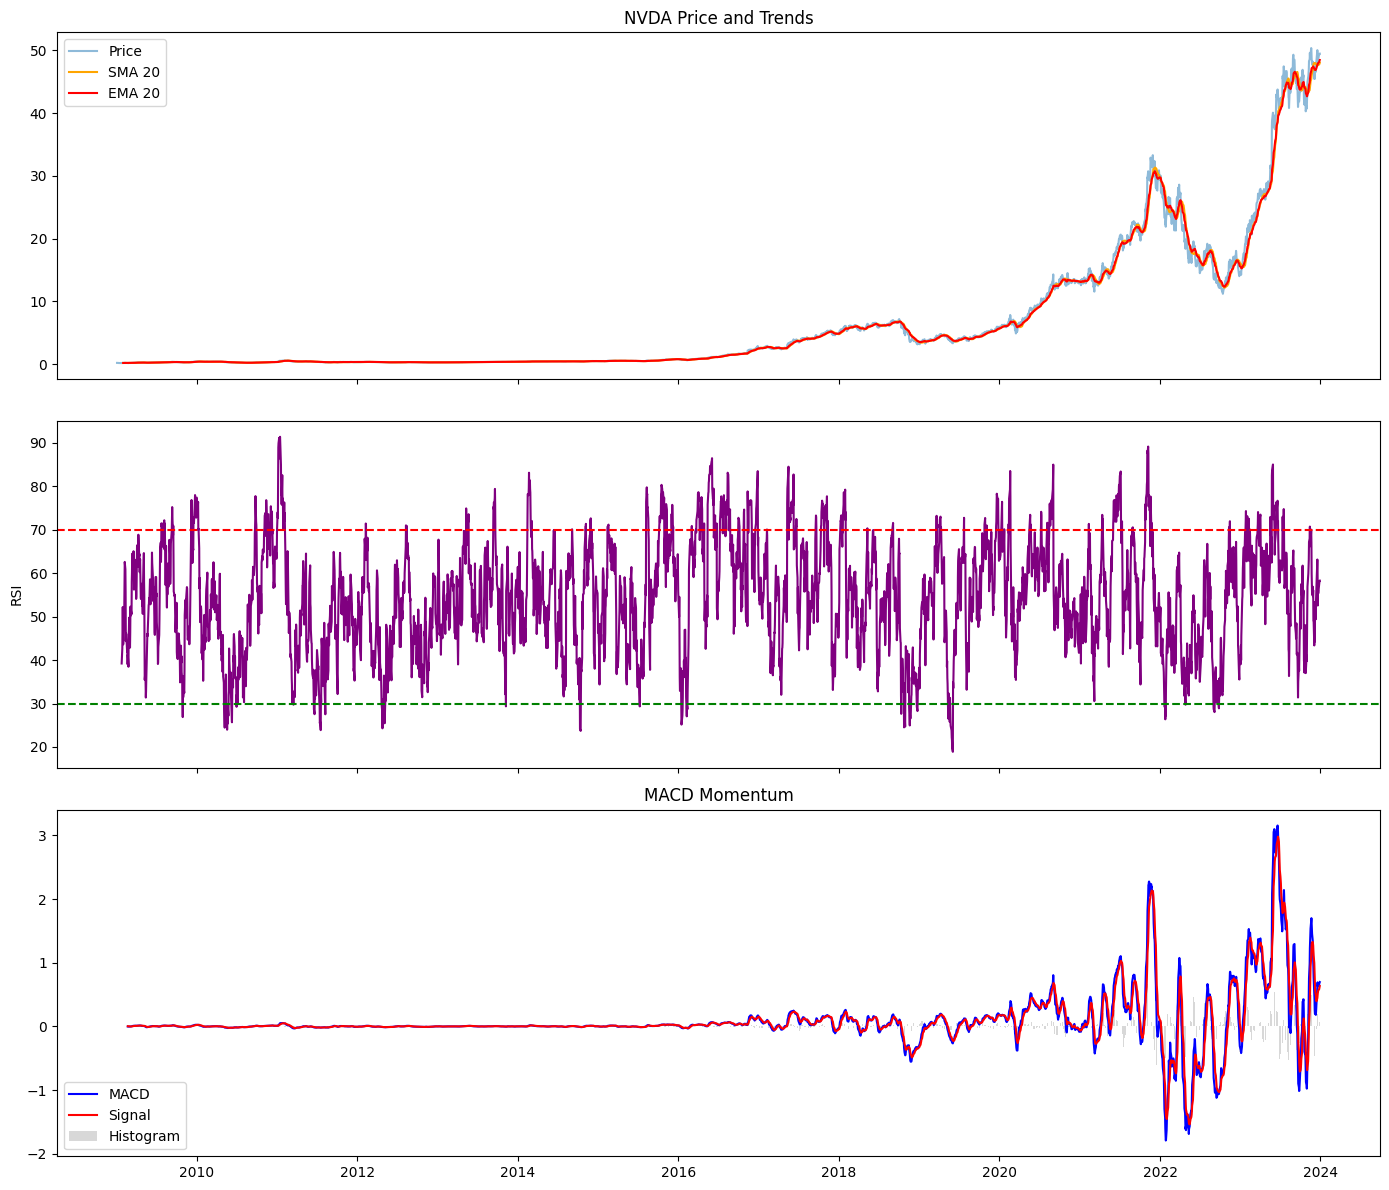

In [4]:
ticker_to_view = 'NVDA'
data = processed_data[ticker_to_view]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14, 12))

# Subplot 1: Price and Moving Averages
# CHANGED: Use 'target_price' instead of 'Adj Close'
ax1.plot(data.index, data['target_price'], label='Price', alpha=0.5) 
ax1.plot(data.index, data['SMA_20'], label='SMA 20', color='orange')
ax1.plot(data.index, data['EMA_20'], label='EMA 20', color='red')
ax1.set_title(f'{ticker_to_view} Price and Trends')
ax1.legend()

# Subplot 2: RSI
ax2.plot(data.index, data['RSI'], color='purple')
ax2.axhline(70, color='red', linestyle='--')
ax2.axhline(30, color='green', linestyle='--')
ax2.set_ylabel('RSI')

# Subplot 3: MACD
ax3.bar(data.index, data['MACD_hist'], label='Histogram', color='gray', alpha=0.3)
ax3.plot(data.index, data['MACD'], label='MACD', color='blue')
ax3.plot(data.index, data['MACD_signal'], label='Signal', color='red')
ax3.set_title('MACD Momentum')
ax3.legend()

plt.tight_layout()
plt.show()